In [4]:
# -*- coding: utf-8 -*-
"""
hmm_factor 因子收益检验 —— Ricequant 研究环境
数据格式: date, order_book_id, hmm_factor, ...（order_book_id 已为米筐格式）
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============ 参数区（按需修改） ============
FACTOR_FILE   = 'gru_factor.csv'   # 上传后的文件名
FACTOR_COL    = 'gru_score'       # 因子列名
HOLDING_PERIOD = 5                 # 持有期（交易日），因子为周频→取5
N_GROUPS      = 5                  # 分组数（5 或 10）
SHIFT_DAYS    = 1                  # T日因子收盘后才知道，T+1才能交易，滞后1期
BENCHMARK     = '000905.XSHG'      # 基准（中证500），可改 '000300.XSHG'
# ===========================================

# 读取因子
factor_df = pd.read_csv(FACTOR_FILE, encoding='utf-8-sig')
factor_df['date'] = pd.to_datetime(factor_df['date'])
factor_df = factor_df[['date', 'order_book_id', FACTOR_COL]].dropna()

# 透视成 宽表：index=date, columns=order_book_id
factor_wide = factor_df.pivot(index='date', columns='order_book_id', values=FACTOR_COL).sort_index()

start_date = factor_wide.index.min()
end_date   = factor_wide.index.max()
stock_list = factor_wide.columns.tolist()

print(f"因子日期范围: {start_date.date()} ~ {end_date.date()}")
print(f"调仓期数: {len(factor_wide)},  股票数: {len(stock_list)}")
factor_wide.iloc[:3, :5]

因子日期范围: 2021-05-17 ~ 2026-08-31
调仓期数: 258,  股票数: 774


order_book_id,000008.XSHE,000009.XSHE,000012.XSHE,000021.XSHE,000027.XSHE
date,,,,,
2021-05-17,0.722826,1.139174,0.421050,0.647394,-1.080832
2021-05-24,0.737472,1.159472,0.451773,0.641309,-1.064565
2021-05-31,0.727866,0.841118,0.575505,0.642781,-1.304581


In [5]:
# 取后复权收盘价（post adjust，避免未来函数；研究环境无需 import/init rqdatac）
# 多取 HOLDING_PERIOD + SHIFT_DAYS 个交易日的价格，保证最后一期因子也能算出收益
price_end = pd.to_datetime(get_trading_dates(start_date, end_date))  # 对齐交易日
extra_dates = pd.to_datetime(get_trading_dates(end_date, 
                (end_date + pd.Timedelta(days=3 * (HOLDING_PERIOD + SHIFT_DAYS + 10)))))

close = get_price(stock_list,
                  start_date=start_date,
                  end_date=extra_dates[-1] if len(extra_dates) > 0 else end_date,
                  fields='close',
                  adjust_type='post',      # 后复权
                  expect_df=False)

# close 为 DataFrame: index=date, columns=order_book_id
close = close.sort_index()

# T+SHIFT 买入、T+SHIFT+HOLDING 卖出 的未来收益
buy_price  = close.shift(-SHIFT_DAYS)
sell_price = close.shift(-(SHIFT_DAYS + HOLDING_PERIOD))
forward_ret = sell_price / buy_price - 1

# 与因子日期对齐（只保留因子存在的调仓日）
forward_ret = forward_ret.reindex(factor_wide.index)
print("未来收益矩阵:", forward_ret.shape)
forward_ret.iloc[:3, :5]

未来收益矩阵: (258, 774)


,000008.XSHE,000009.XSHE,000012.XSHE,000021.XSHE,000027.XSHE
date,,,,,
2021-05-17,0.004405,-0.015075,0.005549,0.009681,0.001927
2021-05-24,0.000000,0.025510,0.108168,0.003384,0.094231
2021-05-31,-0.004386,0.212935,-0.013944,0.011804,-0.087873


===== Pearson IC =====
IC 均值      : 0.0494
IC 标准差    : 0.1319
ICIR         : 0.3747
IC > 0 占比  : 64.98%
t 统计量     : 6.01

===== Rank IC =====
IC 均值      : 0.0649
IC 标准差    : 0.1132
ICIR         : 0.5728
IC > 0 占比  : 69.26%
t 统计量     : 9.18



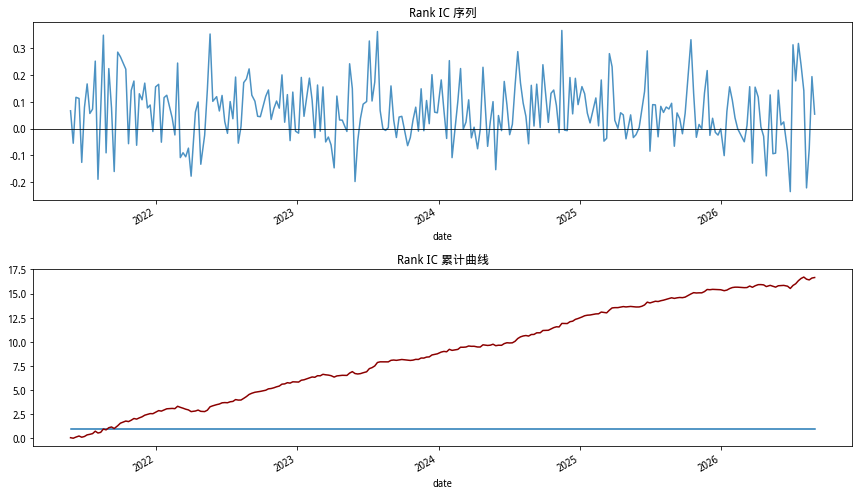

In [6]:
# 每期截面上的 Pearson IC 与 Spearman RankIC
ic_list, rank_ic_list = [], []
for dt in factor_wide.index:
    f = factor_wide.loc[dt]
    r = forward_ret.loc[dt]
    valid = f.notna() & r.notna()
    if valid.sum() < 30:          # 截面股票太少则跳过
        continue
    ic_list.append(stats.pearsonr(f[valid], r[valid])[0])
    rank_ic_list.append(stats.spearmanr(f[valid], r[valid])[0])

ic_s = pd.Series(ic_list, index=factor_wide.index[-len(ic_list):])
ric_s = pd.Series(rank_ic_list, index=factor_wide.index[-len(rank_ic_list):])

def ic_report(s, name):
    print(f"===== {name} =====")
    print(f"IC 均值      : {s.mean():.4f}")
    print(f"IC 标准差    : {s.std():.4f}")
    print(f"ICIR         : {s.mean()/s.std():.4f}")
    print(f"IC > 0 占比  : {(s > 0).mean():.2%}")
    print(f"t 统计量     : {s.mean()/s.std()*np.sqrt(len(s)):.2f}")
    print()

ic_report(ic_s, 'Pearson IC')
ic_report(ric_s, 'Rank IC')

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
ric_s.plot(ax=axes[0], title='Rank IC 序列', alpha=0.8)
axes[0].axhline(0, color='k', lw=0.8)
(1 + 0 * ric_s).plot(ax=axes[1], legend=False)   # 占位
ric_s.cumsum().plot(ax=axes[1], title='Rank IC 累计曲线', color='darkred')
plt.tight_layout()
plt.show()

===== 分组年化收益（已扣费） =====
G1     -9.69%
G2      1.40%
G3      6.54%
G4      7.08%
G5     18.07%
L-S    27.77%
dtype: object

===== 平均单期换手率 =====
G1     39.92%
G2     91.86%
G3    103.32%
G4     93.32%
G5     50.54%
dtype: object


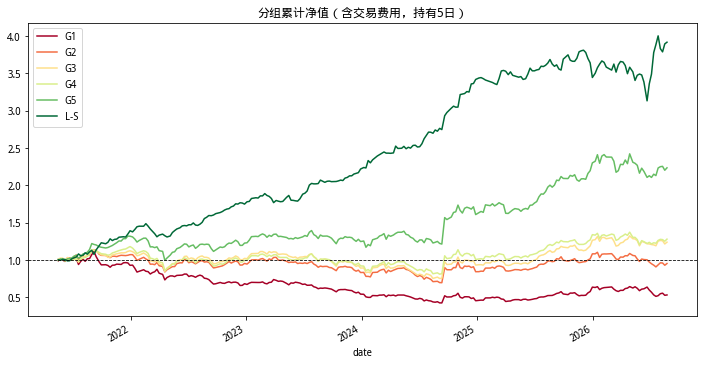

In [12]:
# ============ 分层回测（全口径含交易费用） ============
COMMISSION = 0.0002      # 佣金万2（双边各收一次）
STAMP_TAX  = 0.0005      # 印花税（仅卖出，2023年8月起0.05%）
SLIPPAGE   = 0.001       # 滑点（双边各千1，可按需调整）
COST_BUY   = COMMISSION + SLIPPAGE
COST_SELL  = COMMISSION + STAMP_TAX + SLIPPAGE

group_ret = pd.DataFrame(index=factor_wide.index,
                         columns=[f'G{i+1}' for i in range(N_GROUPS)])
turnover_stat = {f'G{i+1}': [] for i in range(N_GROUPS)}
prev_holdings = {g: set() for g in range(N_GROUPS)}

for i, dt in enumerate(factor_wide.index):
    f = factor_wide.loc[dt].dropna()
    r = forward_ret.loc[dt]
    if len(f) < N_GROUPS * 10:
        continue
    q = pd.qcut(f.rank(method='first'), N_GROUPS, labels=False)

    for g in range(N_GROUPS):
        cur = set(f.index[q == g])
        valid = [s for s in cur if pd.notna(r.get(s))]
        if not valid:
            continue
        gross = r[valid].mean()

        # 换手率：上期持仓中掉出本组的比例 + 新进入的比例
        pre = prev_holdings[g]
        if i == 0 or not pre:
            turn = 1.0                            # 首期全仓建仓
        else:
            sell_ratio = 1 - len(pre & cur) / max(len(pre), 1)
            buy_ratio  = 1 - len(pre & cur) / max(len(cur), 1)
            turn = sell_ratio + buy_ratio
        turnover_stat[f'G{g+1}'].append(turn)

        # 净收益 = 毛收益 - 换手成本（卖出按卖出费率、买入按买入费率）
        cost = sell_ratio * COST_SELL + buy_ratio * COST_BUY if i > 0 and pre else COST_BUY
        group_ret.loc[dt, f'G{g+1}'] = gross - cost
        prev_holdings[g] = cur

group_ret = group_ret.astype(float).dropna(how='all')
group_ret['L-S'] = group_ret[f'G{N_GROUPS}'] - group_ret['G1']

ann = 252 / HOLDING_PERIOD
print("===== 分组年化收益（已扣费） =====")
print((group_ret.mean() * ann).apply(lambda x: f"{x:.2%}"))
print("\n===== 平均单期换手率 =====")
print(pd.Series({k: f"{np.mean(v):.2%}" for k, v in turnover_stat.items()}))

(1 + group_ret.fillna(0)).cumprod().plot(figsize=(12, 6),
    title=f'分组累计净值（含交易费用，持有{HOLDING_PERIOD}日）', colormap='RdYlGn')
plt.axhline(1, color='k', lw=0.8, ls='--')
plt.show()

In [13]:
def perf_stats(ret_s, periods_per_year):
    ret_s = ret_s.dropna()
    nav = (1 + ret_s).cumprod()
    ann_ret = nav.iloc[-1] ** (periods_per_year / len(ret_s)) - 1
    ann_vol = ret_s.std() * np.sqrt(periods_per_year)
    sharpe  = ann_ret / ann_vol if ann_vol != 0 else np.nan
    mdd     = ((nav - nav.cummax()) / nav.cummax()).min()
    win     = (ret_s > 0).mean()
    return pd.Series({'年化收益': ann_ret, '年化波动': ann_vol,
                      '夏普比率': sharpe, '最大回撤': mdd, '单期胜率': win})

# 毛收益 vs 净收益 并排对比
compare = pd.DataFrame({
    '多头G5_毛': perf_stats(group_ret_gross[f'G{N_GROUPS}'], ann),
    '多头G5_净': perf_stats(group_ret_net[f'G{N_GROUPS}'], ann),
    '多空LS_毛': perf_stats(group_ret_gross['L-S'], ann),
    '多空LS_净': perf_stats(group_ret_net['L-S'], ann),
})

fmt = compare.copy()
for c in ['年化收益', '年化波动', '最大回撤', '单期胜率']:
    fmt.loc[c] = fmt.loc[c].apply(lambda x: f"{x:.2%}")
fmt.loc['夏普比率'] = fmt.loc['夏普比率'].apply(lambda x: f"{x:.2f}")
print(fmt)

       多头G5_毛   多头G5_净   多空LS_毛   多空LS_净
年化收益   21.47%   17.08%   31.71%   30.70%
年化波动   21.92%   21.92%   13.67%   13.66%
夏普比率     0.98     0.78     2.32     2.25
最大回撤  -23.63%  -24.55%  -17.62%  -17.80%
单期胜率   57.20%   56.03%   63.42%   62.65%


===== 多头组 G5 相对 000905.XSHG 的超额 =====
     超额年化收益 超额年化波动   信息比率IR  超额单期胜率
毛口径  15.79%  9.98%  158.27%  64.98%
净口径  12.10%  9.98%  121.26%  62.65%


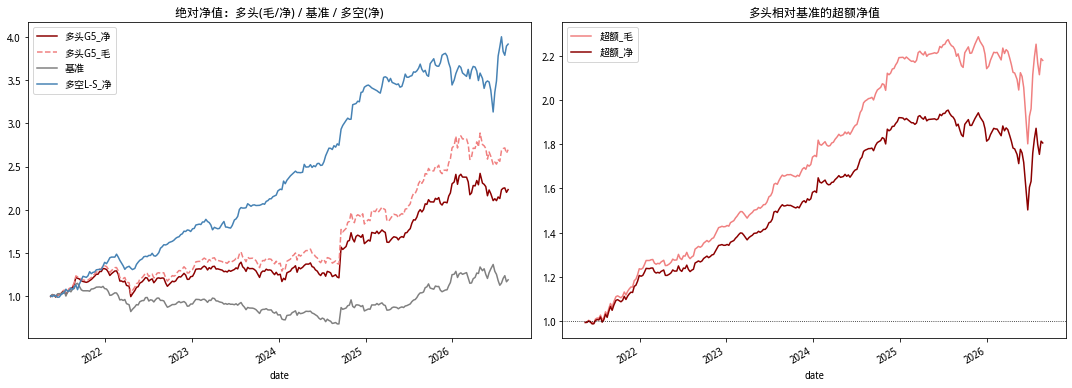

In [11]:
# ============ 与基准对比（毛/净口径 + 超额收益） ============
bench = get_price(BENCHMARK, start_date=start_date, end_date=extra_dates[-1],
                  fields='close', adjust_type='post')

if isinstance(bench.index, pd.MultiIndex):
    bench_close = bench['close'].droplevel('order_book_id')   # 拍平为日期索引
else:
    bench_close = bench['close']

bench_ret = (bench_close.shift(-(SHIFT_DAYS + HOLDING_PERIOD))
             / bench_close.shift(-SHIFT_DAYS) - 1)
bench_ret = bench_ret.reindex(group_ret_net.index)   # 与调仓日对齐

# ---- 超额收益（指增口径：多头净收益 - 基准） ----
excess_gross = group_ret_gross[f'G{N_GROUPS}'] - bench_ret
excess_net   = group_ret_net[f'G{N_GROUPS}'] - bench_ret

excess_summary = pd.DataFrame({
    '超额年化收益': [excess_gross.mean() * ann, excess_net.mean() * ann],
    '超额年化波动': [excess_gross.std() * np.sqrt(ann), excess_net.std() * np.sqrt(ann)],
    '信息比率IR':   [excess_gross.mean() / excess_gross.std() * np.sqrt(ann),
                     excess_net.mean() / excess_net.std() * np.sqrt(ann)],
    '超额单期胜率': [(excess_gross > 0).mean(), (excess_net > 0).mean()],
}, index=['毛口径', '净口径'])
print("===== 多头组 G{} 相对 {} 的超额 =====".format(N_GROUPS, BENCHMARK))
print(excess_summary.applymap(lambda x: f"{x:.2%}" if abs(x) < 10 else f"{x:.2f}"))

# ---- 净值对比图 ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# 左图：绝对净值（毛/净/基准）
(1 + pd.DataFrame({
    f'多头G{N_GROUPS}_净': group_ret_net[f'G{N_GROUPS}'],
    f'多头G{N_GROUPS}_毛': group_ret_gross[f'G{N_GROUPS}'],
    '基准': bench_ret,
    '多空L-S_净': group_ret_net['L-S'],
}).fillna(0)).cumprod().plot(
    ax=axes[0], title='绝对净值：多头(毛/净) / 基准 / 多空(净)',
    style=['-', '--', '-', '-'],
    color=['darkred', 'lightcoral', 'gray', 'steelblue'])

# 右图：超额净值（毛/净）
(1 + pd.DataFrame({'超额_毛': excess_gross, '超额_净': excess_net}
    ).fillna(0)).cumprod().plot(
    ax=axes[1], title=f'多头相对基准的超额净值', color=['lightcoral', 'darkred'])
axes[1].axhline(1, color='k', lw=0.8, ls=':')

plt.tight_layout()
plt.show()